C:\Users\Ayush\AppData\Local\Temp\ipykernel_18848\2021867240.py:26: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq('1H').ffill()


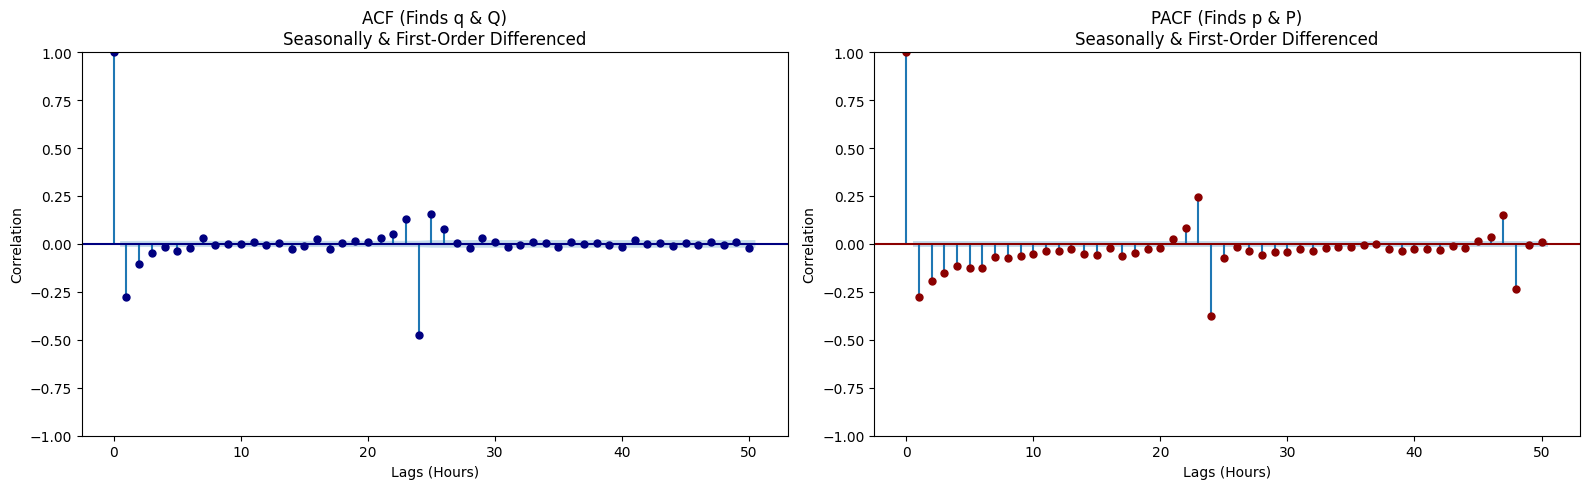

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ==========================================
# 1. LOAD & PREP HOURLY DATA
# ==========================================
df = pd.read_csv(r"C:\Users\Ayush\Desktop\surge\kuppam\Hourly_Data_220kV.csv")

# Create the Datetime column
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df = df.dropna(subset=['Datetime'])

# --- THE FIX: Drop the 50 duplicate timestamps ---
df = df.drop_duplicates(subset=['Datetime'], keep='first')

# Now it is safe to set the index
df.set_index('Datetime', inplace=True)

# Clean and convert Load data
df['Total Load (MW)'] = df['Total Load (MW)'].astype(str).str.replace(',', '')
df['Total Load (MW)'] = pd.to_numeric(df['Total Load (MW)'], errors='coerce')

# Set frequency to 1 Hour (Will run perfectly now)
df = df.asfreq('1H').ffill()

# ==========================================
# 2. ISOLATE ALL TRAINING DATA (Exclude last 7 days)
# ==========================================
test_days = 7
forecast_steps = 24 * test_days

# This grabs literally everything EXCEPT the last 7 days
train = df[['Total Load (MW)']].iloc[:-forecast_steps].copy()
series = train['Total Load (MW)']

# ==========================================
# 3. APPLY DIFFERENCING (The Secret Step)
# ==========================================
# 1st: Seasonal Difference (Subtract the load from exactly 24 hours ago)
diff_seasonal = series.diff(24).dropna()

# 2nd: First-Order Difference (Subtract the load from 1 hour ago)
diff_final = diff_seasonal.diff(1).dropna()

# ==========================================
# 4. PLOT THE RESULTS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# We plot up to 50 lags to see at least two full 24-hour cycles
plot_acf(diff_final, lags=50, ax=axes[0], color='navy')
axes[0].set_title('ACF (Finds q & Q)\nSeasonally & First-Order Differenced')
axes[0].set_xlabel('Lags (Hours)')
axes[0].set_ylabel('Correlation')

plot_pacf(diff_final, lags=50, ax=axes[1], color='darkred', method='ywm')
axes[1].set_title('PACF (Finds p & P)\nSeasonally & First-Order Differenced')
axes[1].set_xlabel('Lags (Hours)')
axes[1].set_ylabel('Correlation')

plt.tight_layout()
plt.show()